# Event-related Fields

Event-related fields (ERFs) and event-related potentials (ERPs) are neural responses that are time-locked to specific sensory, cognitive, or motor events. These responses reflect phase-locked neuronal activity elicited by discrete stimuli and are typically measured using magnetoencephalography (MEG) and electroencephalography (EEG), respectively. Both ERFs and ERPs are widely utilized in cognitive and clinical neuroscience to investigate the temporal dynamics of brain processing, enabling researchers to assess how the brain responds to particular tasks or sensory inputs [1,2].

The objective of this section is to compute ERFs in response to visual stimuli and to perform basic visualizations of their temporal evolution and spatial distribution. Specifically, we will analyze the time course of the ERFs and generate topographical maps to illustrate the distribution of activity across the scalp. These analyses provide valuable insights into the timing and localization of brain processes associated with the perception of visual input.

## Preparation
Import the relevant modules

In [1]:
import os.path as op
import os
import mne
from mne_bids import BIDSPath, read_raw_bids 
from mne.viz import plot_evoked_topo
import matplotlib.pyplot as plt
import numpy as np

<frozen importlib._bootstrap>:488: RuntimeWarning: The MNE-Python config file (C:\Users\arakshit\.mne\mne-python.json) is not a valid JSON file and might be corrupted



File overview

The chapter relies on the input file (embedded in the BIDS structure):

< BIDS_ROOT >/derivatives/Analysis/sub-01/ses-01/meg/sub-01_ses-01_task-SpAtt_run-01_epo.fif

#### Set the local paths of the data:


In [2]:
subject = '01'
session = '01'
task = 'SpAtt'  
run = '01'  
meg_suffix = 'meg'
epo_suffix = 'epo'

data_path='E:/Sub_01/Data'

bids_root = op.join(data_path, "Cerca_Spatt_BIDS")
deriv_root = op.join(bids_root, "derivatives/analysis")
bids_path = BIDSPath(subject=subject, session=session,
            task=task, run=run, suffix=epo_suffix, datatype='meg',
            root=deriv_root, extension='.fif', check=False)
print(bids_path.basename,bids_path.fpath)

sub-01_ses-01_task-SpAtt_run-01_epo.fif E:\Sub_01\Data\Cerca_Spatt_BIDS\derivatives\analysis\sub-01\ses-01\meg\sub-01_ses-01_task-SpAtt_run-01_epo.fif


## Read the epochs

To read in the epochs identified in the previous chapter write

In [3]:
epochs = mne.read_epochs(bids_path.fpath,
                         proj = False,
                         preload=True,
                         verbose=False)

In [4]:
epochs

C:\Users\arakshit\mne-python\1.10.1_0\Lib\site-packages\IPython\core\formatters.py:406: RuntimeWarning: The MNE-Python config file (C:\Users\arakshit\.mne\mne-python.json) is not a valid JSON file and might be corrupted
  return method()


<EpochsFIF | 326 events (all good), -0.749 – 2 s (baseline off), ~930.4 MiB, data loaded,
 'cue_Left': 161
 'cue_Right': 165>

## Averaging the trial data

Identify the epochs for the condition with respect to the onset of the left and right cue onset, and then average over trials. Subsequently, apply a bandpass filter at 0.1-30 Hz and crop the data to the time interval from -0.1 to 0.4 s from stimulus onset. 


In [5]:
evoked_left= epochs['cue_Left'].average(method='mean').filter(0.0, 30).crop(-0.1,0.4).apply_baseline(baseline=(-0.1, 0))
evoked_right= epochs['cue_Right'].average(method='mean').filter(0.0, 30).crop(-0.1,0.4).apply_baseline(baseline=(-0.1, 0))


Setting up low-pass filter at 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 331 samples (0.441 s)

Applying baseline correction (mode: mean)


C:\Users\arakshit\AppData\Local\Temp\ipykernel_41964\1193533615.py:1: RuntimeWarning: The MNE-Python config file (C:\Users\arakshit\.mne\mne-python.json) is not a valid JSON file and might be corrupted
  evoked_left= epochs['cue_Left'].average(method='mean').filter(0.0, 30).crop(-0.1,0.4).apply_baseline(baseline=(-0.1, 0))
C:\Users\arakshit\AppData\Local\Temp\ipykernel_41964\1193533615.py:1: RuntimeWarning: The MNE-Python config file (C:\Users\arakshit\.mne\mne-python.json) is not a valid JSON file and might be corrupted
  evoked_left= epochs['cue_Left'].average(method='mean').filter(0.0, 30).crop(-0.1,0.4).apply_baseline(baseline=(-0.1, 0))


Setting up low-pass filter at 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 331 samples (0.441 s)

Applying baseline correction (mode: mean)


C:\Users\arakshit\AppData\Local\Temp\ipykernel_41964\1193533615.py:2: RuntimeWarning: The MNE-Python config file (C:\Users\arakshit\.mne\mne-python.json) is not a valid JSON file and might be corrupted
  evoked_right= epochs['cue_Right'].average(method='mean').filter(0.0, 30).crop(-0.1,0.4).apply_baseline(baseline=(-0.1, 0))
C:\Users\arakshit\AppData\Local\Temp\ipykernel_41964\1193533615.py:2: RuntimeWarning: The MNE-Python config file (C:\Users\arakshit\.mne\mne-python.json) is not a valid JSON file and might be corrupted
  evoked_right= epochs['cue_Right'].average(method='mean').filter(0.0, 30).crop(-0.1,0.4).apply_baseline(baseline=(-0.1, 0))


Now isolate the Z-sensors as they are ones with the orientation (axis) corresponding to magnetometers in a conventional MEG system:

In [6]:
OPMX = [item for item in epochs.ch_names if item.endswith("X")]
OPMY = [item for item in epochs.ch_names if item.endswith("Y")]
OPMZ = [item for item in epochs.ch_names if item.endswith("Z") and not item.startswith("BNC")]
evoked_left = evoked_left.pick_channels(OPMZ)
evoked_right = evoked_right.pick_channels(OPMZ)

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


A butterfly-plot allows for visualising the event-related fields across sensors:

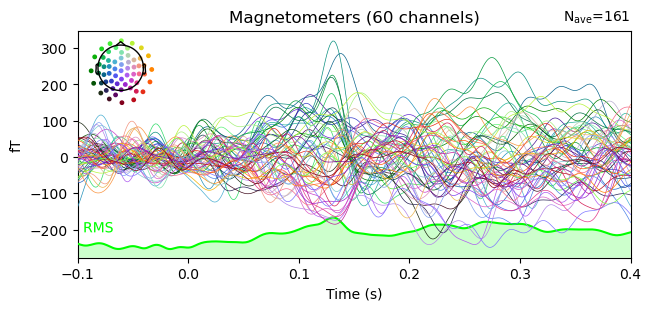

In [7]:
evoked_left.plot(gfp=True);

Here, note the large positive and negative event-related fields at respectively t = 0.170 s and t = 0.187 s

## Plotting the event-related fields arranged topographically according to senors locations

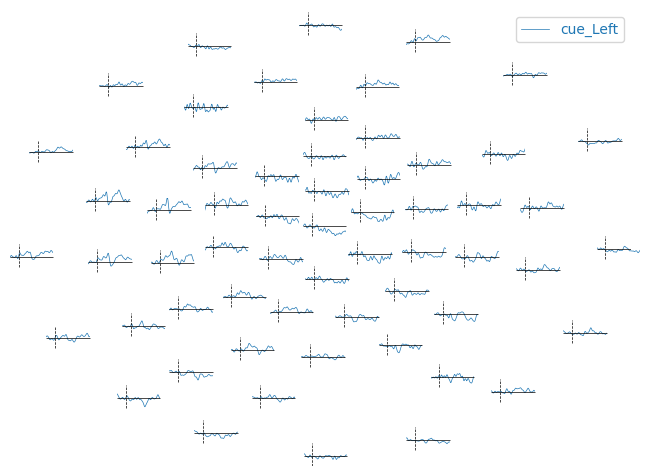

In [8]:
%matplotlib inline
evoked_left.plot_topo();

To enable interactive plotting, use %matplotlib qt instead of %matplotlib inline. This allows you to click on individual sensor plots to enlarge and inspect them in more detail.

## To plot a topographic map of the response at any specific instant of time write:

Since the Cerca/Quspin system uses triaxial sensors that measure the magnetic field along three mutually orthogonal directions, it is important to identify and separate the components corresponding to each direction and plot them individually.

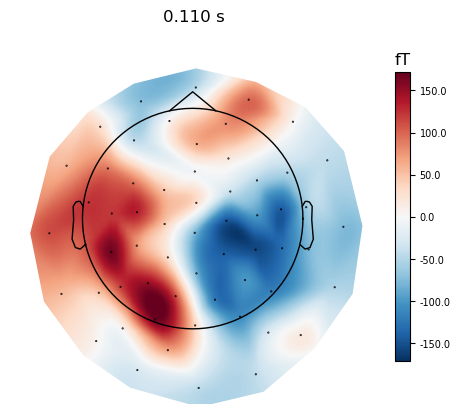

In [13]:
evoked_left.plot_topomap(times=[0.110],
    contours = 0,
    ch_type='mag',
    size=3,
    show_names=False,
    extrapolate = 'local',
    outlines = 'head'
);


**Question 1**: Explain how an equivalent current dipole (ECD) can account for the posterior event-related field by drawing the ECD on top of the topographic plot (hint: consider the 'right-hand rule')

Now plot the topographic maps across multiple time points

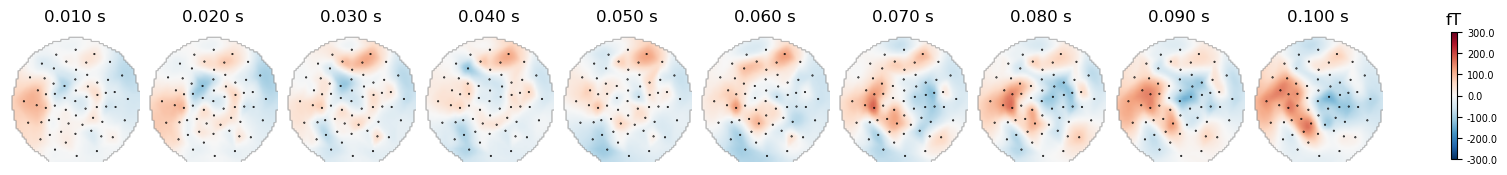

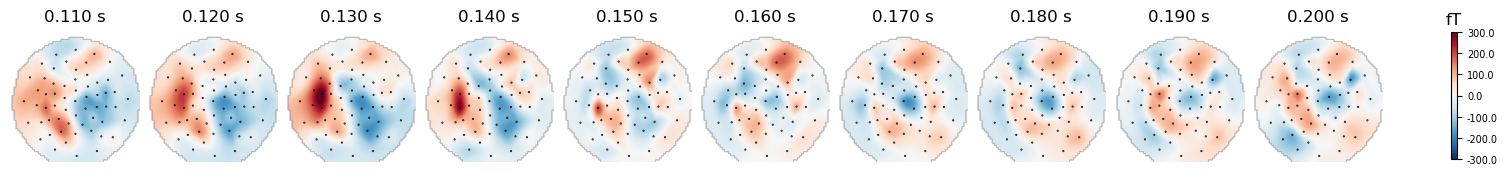

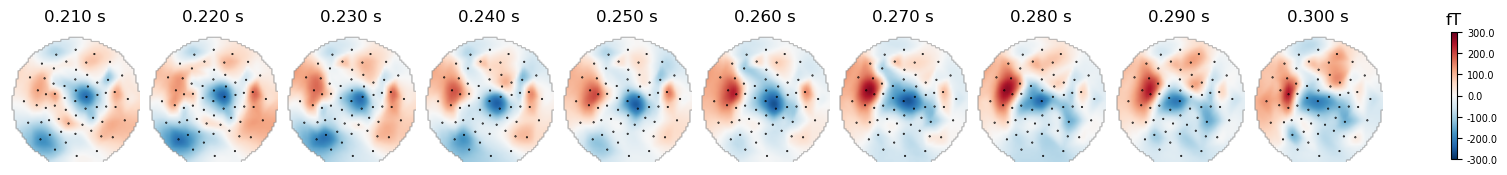

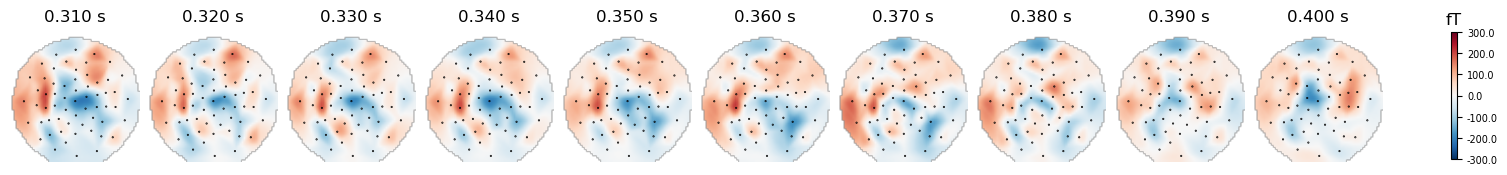

In [10]:
time_ins1 = np.linspace(0.01, 0.1, num=10) #define time points
time_ins2 = np.linspace(0.11, 0.2, num=10) #define time points
time_ins3 = np.linspace(0.21, 0.3, num=10) #define time points
time_ins4 = np.linspace(0.31, 0.4, num=10) #define time points
evoked_left.plot_topomap(times=time_ins1, ch_type='mag', extrapolate = 'local', contours = 0, outlines = None,vlim = (-300,300));
evoked_left.plot_topomap(times=time_ins2, ch_type='mag', extrapolate = 'local', contours = 0, outlines = None,vlim = (-300,300));
evoked_left.plot_topomap(times=time_ins3, ch_type='mag', extrapolate = 'local', contours = 0, outlines = None,vlim = (-300,300));
evoked_left.plot_topomap(times=time_ins4, ch_type='mag', extrapolate = 'local', contours = 0, outlines = None,vlim = (-300,300));

**Question 2**: Generate the ERFs with respect to the onset of the gratings.

## Preregistration and publications

Publication, example:

"Prior to the computation of event-related fields (ERFs), the MEG data were band-pass filtered between 0.1 and 30 Hz to attenuate slow drifts and high-frequency noise. This filtering was performed using a non-causal finite impulse response (FIR) filter, designed with a Hamming window and a filter length of 331 samples. Following filtering, epochs were averaged across trials and baseline correction was then applied by subtracting the mean signal within a 100 ms pre-stimulus interval."



## References
1. Woodman, G. F. (2010). A brief introduction to the use of event-related potentials in studies of perception and attention. *Attention, Perception, & Psychophysics*, *72*(8), 2031–2046. https://doi.org/10.3758/APP.72.8.2031

2. Luck, S. J. (2014). *An Introduction to the Event-Related Potential Technique* (2nd ed.). Bradford Books.
